In [1]:
def set_mpl_params(dpi=150, figsize=(9, 6), grid=True, font_size=16, font_family='serif'):
    """Configure matplotlib parameters for consistent plot styling.
    
    Args:
        dpi (int): Output resolution
        figsize (tuple): Figure dimensions (width, height) in inches
        grid (bool): Toggle grid display
        font_size (int): Base font size
        font_family (str): Font family for text elements
    """
    import matplotlib as mpl
    mpl.rcParams.update({
        'figure.dpi': dpi,
        'figure.figsize': figsize,
        'font.size': font_size,
        'font.family': font_family
    })

set_mpl_params()

## Preamble

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

## Question 1
### Part 3

True Parameters: μ = 50, σ² = 25
MLE Estimates: μ_MLE = 49.91, σ̂²_MLE = 25.96


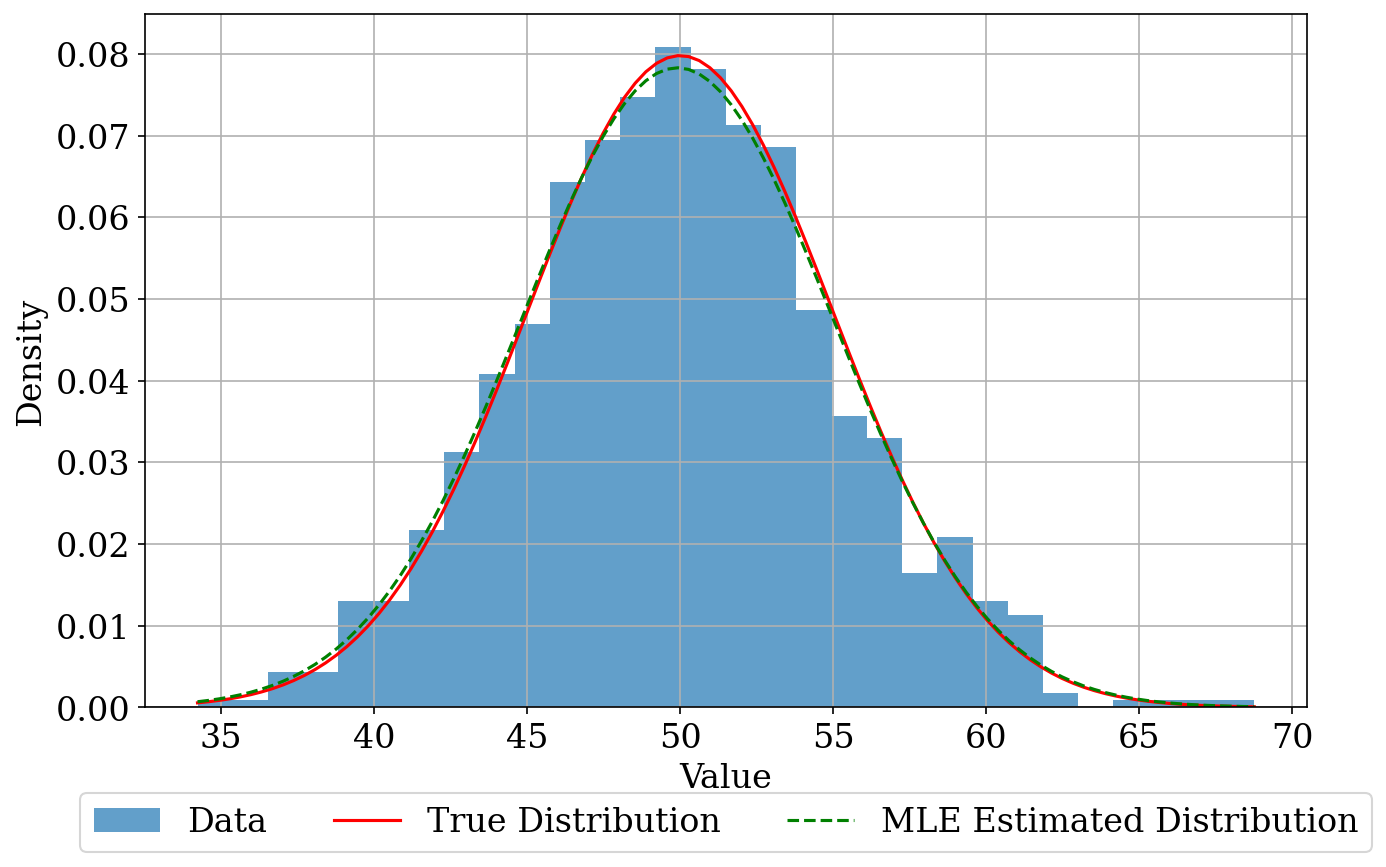

In [3]:
# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

class NormalDistributionMLE:
    def __init__(self, true_mean=50, true_variance=25, sample_size=1000):
        self.true_mean = true_mean
        self.true_variance = true_variance
        self.sample_size = sample_size
        self.data = self._generate_data()
    
    def _generate_data(self):
        """Generate synthetic data from normal distribution"""
        return [random.gauss(self.true_mean, self.true_variance**0.5) 
                for _ in range(self.sample_size)]
    
    def compute_mle_mean(self):
        """Compute MLE for mean"""
        return sum(self.data) / len(self.data)
    
    def compute_mle_variance(self):
        """Compute MLE for variance"""
        mean = self.compute_mle_mean()
        squared_errors = [(x - mean)**2 for x in self.data]
        return sum(squared_errors) / len(self.data)
    
    def plot_distribution(self):
        """Plot histogram of data with true and estimated parameters"""
        plt.figure(figsize=(10, 6))
        plt.hist(self.data, bins=30, density=True, alpha=0.7, label='Data')
        
        # Generate points for the true normal distribution
        x = np.linspace(min(self.data), max(self.data), 100)
        y_true = np.exp(-(x - self.true_mean)**2 / (2*self.true_variance)) / np.sqrt(2*np.pi*self.true_variance)
        plt.plot(x, y_true, 'r-', label='True Distribution')
        
        # Generate points for the estimated normal distribution
        mle_mean = self.compute_mle_mean()
        mle_var = self.compute_mle_variance()
        y_est = np.exp(-(x - mle_mean)**2 / (2*mle_var)) / np.sqrt(2*np.pi*mle_var)
        plt.plot(x, y_est, 'g--', label='MLE Estimated Distribution')
        
        # Labeling the axes
        plt.xlabel('Value')
        plt.ylabel('Density')
        
        # Adjusting the legend position
        plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
        plt.grid(True)
        plt.show()

# Create instance and compute MLEs
mle = NormalDistributionMLE(true_mean=50, true_variance=25, sample_size=1000)
mle_mean = mle.compute_mle_mean()
mle_variance = mle.compute_mle_variance()

print(f"True Parameters: μ = {mle.true_mean}, σ² = {mle.true_variance}")
print(f"MLE Estimates: μ_MLE = {mle_mean:.2f}, σ̂²_MLE = {mle_variance:.2f}")
# Visualize the results
mle.plot_distribution()

## Question 3

Test Accuracy: 0.923


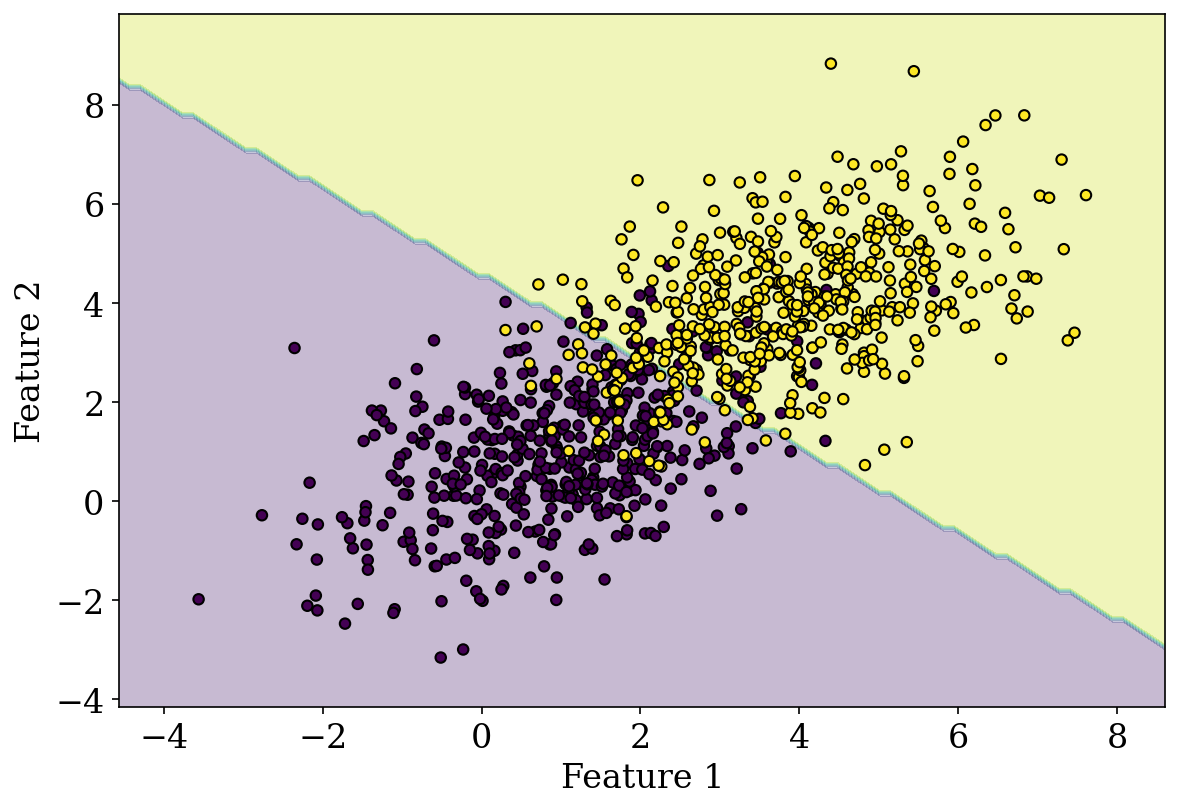

In [13]:
np.random.seed(42)
# Data generation
n_samples = 1000
mean1 = [1, 1]
mean2 = [4, 4]
cov = [[2, 1], [1, 2]]

X1 = np.random.multivariate_normal(mean1, cov, n_samples//2)
X2 = np.random.multivariate_normal(mean2, cov, n_samples//2)
X = np.vstack((X1, X2))
y = np.hstack((np.zeros(n_samples//2), np.ones(n_samples//2)))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# LDA implementation
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Evaluation
y_pred = lda.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.3f}")

# Decision boundary plotting
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = lda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k', s=25)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## Question 4

Test Accuracy: 0.963


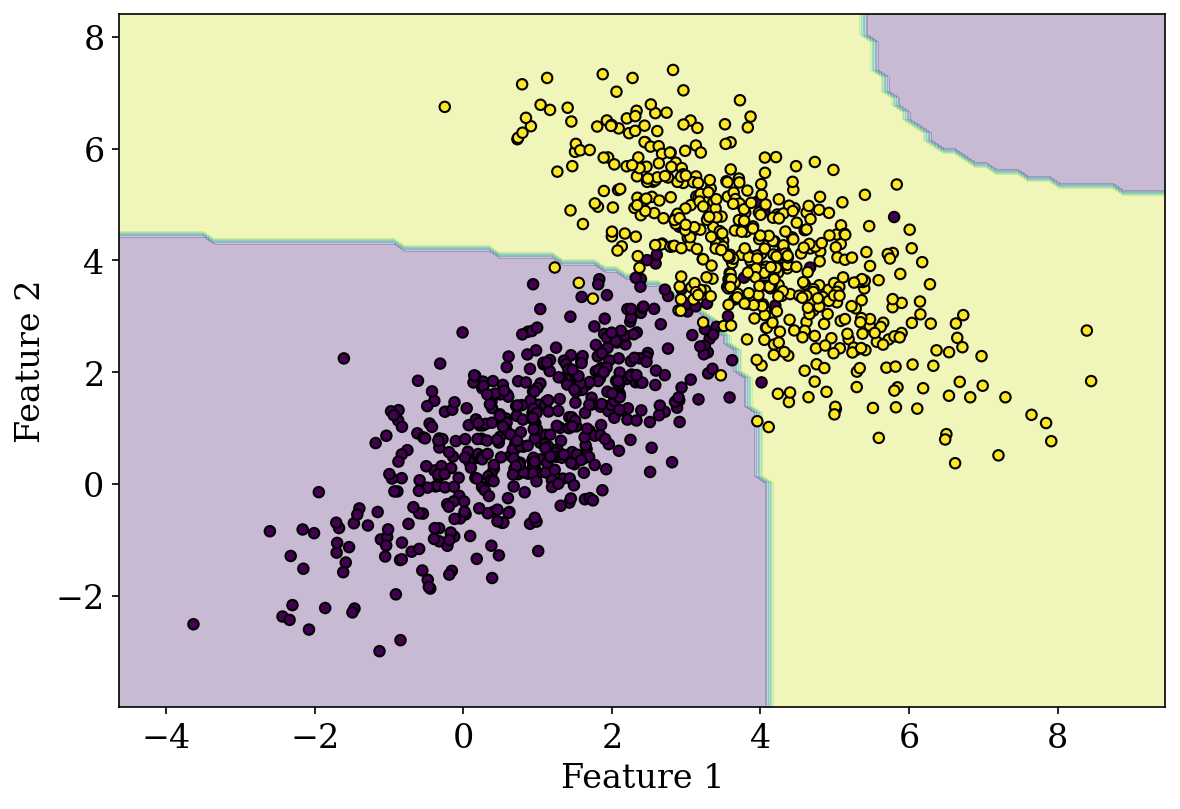

In [19]:
np.random.seed(42)
n_samples = 1000
mean1 = [1, 1]
mean2 = [4, 4]
cov1 = [[2, 1.5], [1.5, 2]]
cov2 = [[2, -1.5], [-1.5, 2]]

X1 = np.random.multivariate_normal(mean1, cov1, n_samples//2)
X2 = np.random.multivariate_normal(mean2, cov2, n_samples//2)
X = np.vstack((X1, X2))
y = np.hstack((np.zeros(n_samples//2), np.ones(n_samples//2)))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# QDA implementation
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

# Evaluation
y_pred = qda.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.3f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)


# Decision boundary plotting
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100))
Z = qda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k', s=25)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


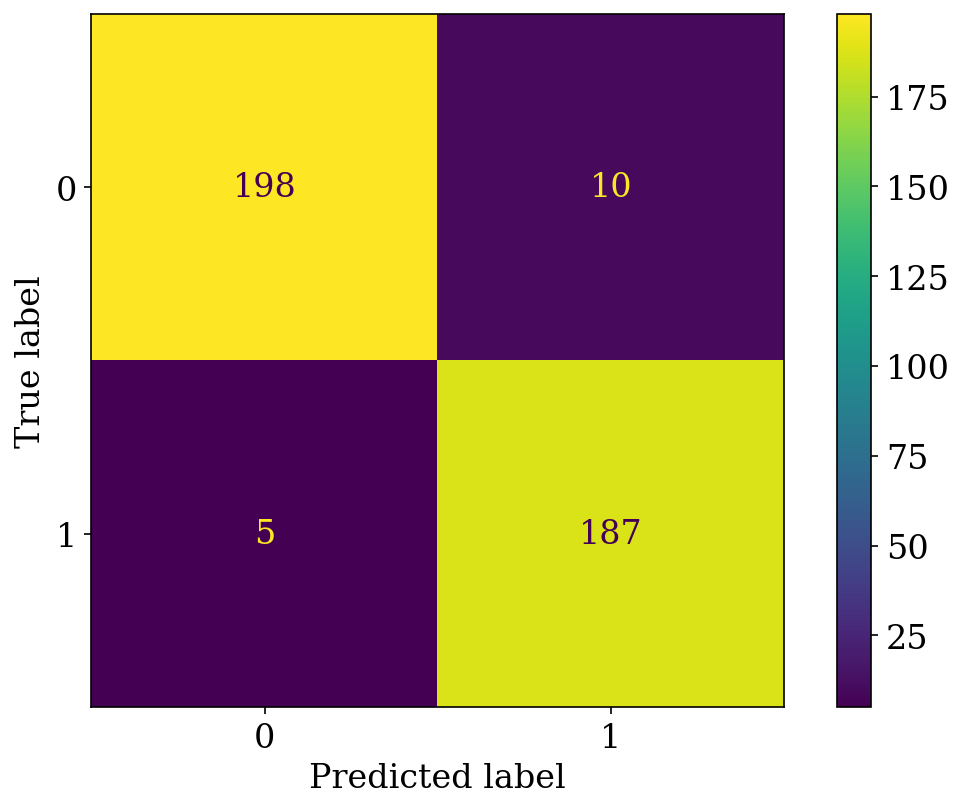

In [20]:
ConfusionMatrixDisplay(cm).plot()

Test Accuracy: 0.922


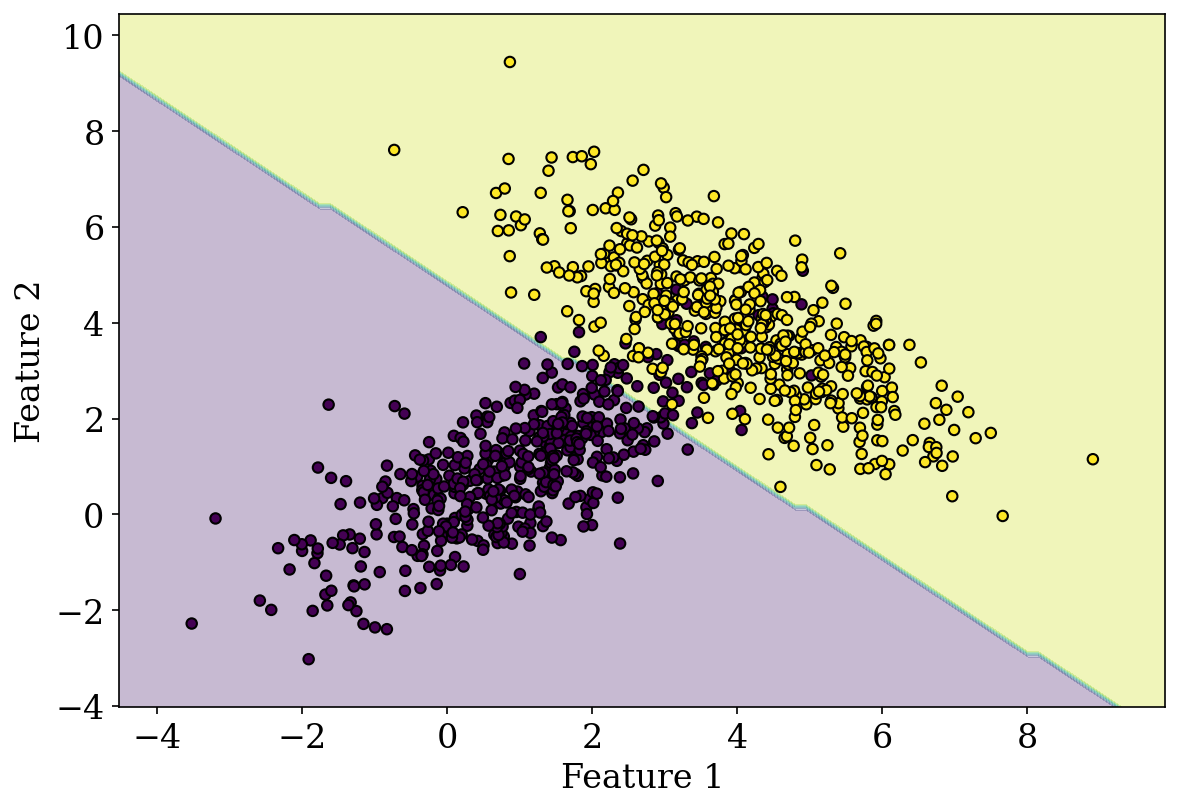

In [7]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Evaluation
y_pred = lda.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.3f}")

# Decision boundary plotting
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = lda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k', s=25)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
